# Quantificando os dados

In [12]:
import os

files = {"fold1_train": [], "fold1_test": [], "fold2_train": [], "fold2_test": [],
         "fold3_train": [], "fold3_test": []}
for fold in ['fold1', 'fold2', 'fold3']:
    for tt in ['train', 'test']:
        for file in os.listdir(f'data/processed/cwru/{fold}/{tt}'):
            key = f"{fold}_{tt}"
            files[key].append(file.split('_')[0])
basenames = {"fold1_train": sorted(set(files['fold1_train'])),
             "fold1_test": sorted(set(files['fold1_test'])),
             "fold2_train": sorted(set(files['fold2_train'])),
             "fold2_test": sorted(set(files['fold2_test'])),
             "fold3_train": sorted(set(files['fold3_train'])),
             "fold3_test": sorted(set(files['fold3_test']))}

for f in basenames.items():
    print(f) 

('fold1_train', ['099', '100', '173', '175', '176', '177', '189', '190', '191', '192', '201', '202', '203', '204', '213', '214', '215', '217', '226', '227', '228', '229', '238', '239', '240', '241'])
('fold1_test', ['098', '109', '110', '111', '112', '122', '123', '124', '125', '135', '136', '137', '138'])
('fold2_train', ['098', '100', '109', '110', '111', '112', '122', '123', '124', '125', '135', '136', '137', '138', '213', '214', '215', '217', '226', '227', '228', '229', '238', '239', '240', '241'])
('fold2_test', ['099', '173', '175', '176', '177', '189', '190', '191', '192', '201', '202', '203', '204'])
('fold3_train', ['098', '099', '109', '110', '111', '112', '122', '123', '124', '125', '135', '136', '137', '138', '173', '175', '176', '177', '189', '190', '191', '192', '201', '202', '203', '204'])
('fold3_test', ['100', '213', '214', '215', '217', '226', '227', '228', '229', '238', '239', '240', '241'])


Quantidade de arquivos com classe N

In [16]:
import os

# arquivos com classe N
files_N = ['098', '099', '100']

files = {"fold1_train": [], "fold1_test": [], "fold2_train": [], "fold2_test": [],
         "fold3_train": [], "fold3_test": []}
for fold in ['fold1', 'fold2', 'fold3']:
    for tt in ['train', 'test']:
        for file in os.listdir(f'data/processed/cwru/{fold}/{tt}'):
            key = f"{fold}_{tt}"
            if file.split('_')[0] in files_N:
                files[key].append(file)
basenames = {"fold1_train": len(files['fold1_train']),
             "fold1_test": len(files['fold1_test']),
             "fold2_train": len(files['fold2_train']),
             "fold2_test": len(files['fold2_test']),
             "fold3_train": len(files['fold3_train']),
             "fold3_test": len(files['fold3_test'])}

for f in basenames.items():
    print(f) 

('fold1_train', 236)
('fold1_test', 118)
('fold2_train', 236)
('fold2_test', 118)
('fold3_train', 236)
('fold3_test', 118)


In [14]:
import os

files = {"fold1_train": [], "fold1_test": [], "fold2_train": [], "fold2_test": [],
         "fold3_train": [], "fold3_test": []}
for fold in ['fold1', 'fold2', 'fold3']:
    for tt in ['train', 'test']:
        for file in os.listdir(f'data/processed/cwru/{fold}/{tt}'):
            key = f"{fold}_{tt}"
            files[key].append(file.split('_')[0])
basenames = {"fold1_train": len(files['fold1_train']),
             "fold1_test": len(files['fold1_test']),
             "fold2_train": len(files['fold2_train']),
             "fold2_test": len(files['fold2_test']),
             "fold3_train": len(files['fold3_train']),
             "fold3_test": len(files['fold3_test'])}

for f in basenames.items():
    print(f) 

('fold1_train', 2654)
('fold1_test', 1359)
('fold2_train', 2722)
('fold2_test', 1291)
('fold3_train', 2650)
('fold3_test', 1363)


# Debug

In [1]:
from src.data_processing.dataset import VibrationDatasetFromMap, VibrationMapBuilder

fold = "fold1"

builder = VibrationMapBuilder(data_dir=f"data/processed/bi/{fold}/train")
train_map, val_map = builder.get_split(val_ratio=0.2, stratify=True)
counter = {"B": 0, "I": 0}
for info in train_map:
    index, label, path = info["index"], info["label"], info["path"]
    # print(index, label, path)
    if label == "B":
        counter["B"] = 1+counter["B"]
    if label == "I":
        counter["I"] = 1+counter["I"]
print(f"Quantidade de dados de treino por classe: {counter}")

counter = {"B": 0, "I": 0}
for info in val_map:
    index, label, path = info["index"], info["label"], info["path"]
    # print(index, label, path)
    if label == "B":
        counter["B"] = 1+counter["B"]
    if label == "I":
        counter["I"] = 1+counter["I"]
print(f"Quantidade de dados de validação por classe: {counter}")

import os
counter = 0
for path in os.listdir("data/processed/bi/fold3/train"):
    # print(path)
    counter += 1

print(f"Totalizando: {counter} amostras.")
print(f"Quantidade de amostras de treino: {len(train_map)}")
print(f"Quantidade de amostras de validação: {len(val_map)}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/bi/fold1/train'

In [5]:
bearings_files_b7 = [(i, "B") for i in [122, 123, 124, 125]]
bearings_files_b14 = [(i, "B") for i in [189, 190, 191, 192]]
bearings_files_b21 = [(i, "B") for i in [226, 227, 228, 229]]
bearings_files_i7 = [(i, "I") for i in [109, 110, 111, 112]]
bearings_files_i14 = [(i, "I") for i in [174, 175, 176, 177]]
bearings_files_i21 = [(i, "I") for i in [213, 214, 215, 217]]
bearings_files_val_n = [(i, "N") for i in [97]],
bearings_files_bval_f1 = [(i, "B") for i in [189, 226]],
bearings_files_bval_f2 = [(i, "B") for i in [122, 226]],
bearings_files_bval_f3 = [(i, "B") for i in [122, 189]],
bearings_files_ival_f1 = [(i, "I") for i in [174, 213]],
bearings_files_ival_f2 = [(i, "I") for i in [109, 213]],
bearings_files_ival_f3 = [(i, "I") for i in [109, 174]],
bearings_files_oval_f1 = [(i, "O") for i in [201, 238]],
bearings_files_oval_f2 = [(i, "O") for i in [135, 238]],
bearings_files_oval_f3 = [(i, "O") for i in [135, 201]],
bearings_files_n7 = [(i, "N") for i in [98]]
bearings_files_n14 = [(i, "N") for i in [99]]
bearings_files_n21 = [(i, "N") for i in [100]]
bearings_files_o7 = [(i, "O") for i in [135, 136, 137, 138]]
bearings_files_o14 = [(i, "O") for i in [201, 202, 203, 204]]
bearings_files_o21 = [(i, "O") for i in [238, 239, 240, 241]]


fold_files_bi = {
    "fold1": {
        "train": bearings_files_b14[1:] + bearings_files_b21[1:] + bearings_files_i14[1:] + bearings_files_i21[1:],
        "test": bearings_files_b7[1:] + bearings_files_i7[1:],
        "val": [bearings_files_b14[0]] + [bearings_files_b21[0]] + [bearings_files_i14[0]] + [bearings_files_i21[0]]
    },
    "fold2": {
        "train": bearings_files_b7[1:] + bearings_files_b21[1:] + bearings_files_i7[1:] + bearings_files_i21[1:],
        "test": bearings_files_b14[1:] + bearings_files_i14[1:],
        "val": [bearings_files_b7[0]] + [bearings_files_b21[0]] + [bearings_files_i7[0]] + [bearings_files_i21[0]]
    },
    "fold3": {
        "train": bearings_files_b7[1:] + bearings_files_b14[1:] + bearings_files_i7[1:] + bearings_files_i14[1:],
        "test": bearings_files_b21[1:] + bearings_files_i21[1:],
        "val": [bearings_files_b7[0]] + [bearings_files_b14[0]] + [bearings_files_i7[0]] + [bearings_files_i14[0]]
    }        
}

fold_files_bo = {
    "fold1": {
        "train": bearings_files_b14[1:] + bearings_files_b21[1:] + bearings_files_o14[1:] + bearings_files_o21[1:],
        "test": bearings_files_b7[1:] + bearings_files_o7[1:],
        "val": [bearings_files_b14[0]] + [bearings_files_b21[0]] + [bearings_files_o14[0]] + [bearings_files_o21[0]]
    },
    "fold2": {
        "train": bearings_files_b7[1:] + bearings_files_b21[1:] + bearings_files_o7[1:] + bearings_files_o21[1:],
        "test": bearings_files_b14[1:] + bearings_files_o14[1:],
        "val": [bearings_files_b7[0]] + [bearings_files_b21[0]] + [bearings_files_o7[0]] + [bearings_files_o21[0]]
    },
    "fold3": {
        "train": bearings_files_b7[1:] + bearings_files_b14[1:] + bearings_files_o7[1:] + bearings_files_o14[1:],
        "test": bearings_files_b21[1:] + bearings_files_o21[1:],
        "val": [bearings_files_b7[0]] + [bearings_files_b14[0]] + [bearings_files_o7[0]] + [bearings_files_o14[0]]
    } 
}

fold_files_io = {
    "fold1": {
        "train": bearings_files_i14[1:] + bearings_files_i21[1:] + bearings_files_o14[1:] + bearings_files_o21[1:],
        "test": bearings_files_i7[1:] + bearings_files_o7[1:],
        "val": [bearings_files_i14[0]] + [bearings_files_i21[0]] + [bearings_files_o14[0]] + [bearings_files_o21[0]]
    },
    "fold2": {
        "train": bearings_files_i7[1:] + bearings_files_i21[1:] + bearings_files_o7[1:] + bearings_files_o21[1:],
        "test": bearings_files_i14[1:] + bearings_files_o14[1:],
        "val": [bearings_files_i7[0]] + [bearings_files_i21[0]] + [bearings_files_o7[0]] + [bearings_files_o21[0]]
    },
    "fold3": {
        "train": bearings_files_i7[1:] + bearings_files_i14[1:] + bearings_files_o7[1:] + bearings_files_o14[1:],
        "test": bearings_files_i21[1:] + bearings_files_o21[1:],
        "val": [bearings_files_i7[0]] + [bearings_files_i14[0]] + [bearings_files_o7[0]] + [bearings_files_o14[0]]
    } 
}

fold_files_bio = {
    "fold1": {
        "train": bearings_files_b14[1:] + bearings_files_b21[1:] + bearings_files_i14[1:] + bearings_files_i21[1:] + bearings_files_o14[1:] + bearings_files_o21[1:],
        "test": bearings_files_b7[1:] + bearings_files_i7[1:] + bearings_files_o7[1:],
        "val": [bearings_files_b14[0]] + [bearings_files_b21[0]] + [bearings_files_i14[0]] + [bearings_files_i21[0]] + [bearings_files_o14[0]] + [bearings_files_o21[0]]
    },
    "fold2": {
        "train": bearings_files_b7[1:] + bearings_files_b21[1:] + bearings_files_i7[1:] + bearings_files_i21[1:] + bearings_files_o7[1:] + bearings_files_o21[1:],
        "test": bearings_files_b14[1:] + bearings_files_i14[1:] + bearings_files_o14[1:],
        "val": [bearings_files_b7[0]] + [bearings_files_b21[0]] + [bearings_files_i7[0]] + [bearings_files_i21[0]] + [bearings_files_o7[0]] + [bearings_files_o21[0]],
    },
    "fold3": {
        "train": bearings_files_b7[1:] + bearings_files_b14[1:] + bearings_files_i7[1:] + bearings_files_i14[1:] + bearings_files_o7[1:] + bearings_files_o14[1:],
        "test": bearings_files_b21[1:] + bearings_files_i21[1:] + bearings_files_o21[1:],
        "val": [bearings_files_b7[0]] + [bearings_files_b14[0]] + [bearings_files_i7[0]] + [bearings_files_i14[0]] + [bearings_files_o7[0]] + [bearings_files_o14[0]]}
}

fold_files = {
    "fold1": {
        "train": bearings_files_b14[1:] + bearings_files_b21[1:] + bearings_files_i14[1:] + bearings_files_i21[1:] + bearings_files_n14 + bearings_files_n21 + bearings_files_o14[1:] + bearings_files_o21[1:],
        "test": bearings_files_b7[1:] + bearings_files_i7[1:] + bearings_files_n7 + bearings_files_o7[1:],
        "val": [bearings_files_b14[0]] + [bearings_files_b21[0]] + [bearings_files_i14[0]] + [bearings_files_i21[0]] + bearings_files_val_n[0] + [bearings_files_o14[0]] + [bearings_files_o21[0]]
    },
    "fold2": {
        "train": bearings_files_b7[1:] + bearings_files_b21[1:] + bearings_files_i7[1:] + bearings_files_i21[1:] + bearings_files_n7 + bearings_files_n21 + bearings_files_o7[1:] + bearings_files_o21[1:],
        "test": bearings_files_b14[1:] + bearings_files_i14[1:] + bearings_files_n14 + bearings_files_o14[1:],
        "val": [bearings_files_b7[0]] + [bearings_files_b21[0]] + [bearings_files_i7[0]] + [bearings_files_i21[0]] + bearings_files_val_n[0] + [bearings_files_o7[0]] + [bearings_files_o21[0]],
    },
    "fold3": {
        "train": bearings_files_b7[1:] + bearings_files_b14[1:] + bearings_files_i7[1:] + bearings_files_i14[1:] + bearings_files_n7 + bearings_files_n14 + bearings_files_o7[1:] + bearings_files_o14[1:],
        "test": bearings_files_b21[1:] + bearings_files_i21[1:] + bearings_files_n21 + bearings_files_o21[1:],
        "val": [bearings_files_b7[0]] + [bearings_files_b14[0]] + [bearings_files_i7[0]] + [bearings_files_i14[0]] + [bearings_files_o7[0]] + [bearings_files_o14[0]] + bearings_files_val_n[0]
    }
}


### Gerador de Espectrogramas

In [2]:
import os
import numpy as np
from scipy.signal import stft
from skimage.transform import resize
import matplotlib
from PIL import Image

def save_signal_spectrogram(
    signal,
    save_path,
    label_name,
    filename,
    fs=48000,
    nperseg=256,
    noverlap=192,
    output_size=(224, 224),
    cmap='inferno'  # pode ser 'plasma', 'inferno', 'jet', etc.
):
    assert len(signal) == 1024, "Signal must be of length 1024"
    assert noverlap < nperseg, "noverlap must be less than nperseg"

    # STFT
    f, t, Zxx = stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
    spec = np.abs(Zxx)
    spec = np.log1p(spec)  # compressão dinâmica

    # Redimensiona
    spec_resized = resize(spec, output_size, mode='reflect', anti_aliasing=True)

    # Normaliza para [0,1]
    spec_resized -= spec_resized.min()
    spec_resized /= spec_resized.max()

    # Aplica colormap → (H, W, 4) com canal alpha
    cmap_func = matplotlib.colormaps.get_cmap(cmap)
    spec_rgb = cmap_func(spec_resized)[..., :3]  # pega só os 3 canais RGB

    # Converte para uint8 e salva
    spec_uint8 = (spec_rgb * 255).astype(np.uint8)
    image = Image.fromarray(spec_uint8)

    # Diretório
    full_dir = os.path.join(save_path, label_name)
    os.makedirs(full_dir, exist_ok=True)

    # Salvar como PNG colorido
    image.save(os.path.join(full_dir, f"{filename}.png"))


### Aumento de Dados em Sinal 1D

In [3]:
import numpy as np

fc = 48000  # Frequência de amostragem típica no CWRU (pode ser ajustada)
f_o = 107.36  # BPFO em Hz
f_i = 162.19  # BPFI em Hz
f_b = 70.58 

# Noise
def add_gaussian_noise(signal, snr_db=10):
    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), size=signal.shape)
    return signal + noise

# Local Reversing
def local_data_reversing(signal, M=10):
        N = len(signal)
        min_len = int(fc / min(f_o, f_i, f_b))
        segment_len = max(N // M, min_len)
        segments = np.array_split(signal[:M * segment_len], M)
        for i in range(len(segments)):
            sub_len = np.random.randint(1, segment_len)
            start = np.random.randint(0, segment_len - sub_len)
            segments[i][start:start+sub_len] = segments[i][start:start+sub_len][::-1]
        return np.concatenate(segments)


def local_random_reversing(signal, q=0.2):
    N = len(signal)
    min_len = int(fc / min(f_o, f_i, f_b))
    seg_len = max(int(q * N), min_len)
    start = np.random.randint(0, N - seg_len)
    signal[start:start+seg_len] = signal[start:start+seg_len][::-1]
    return signal

def global_data_reversing(signal):
    return signal[::-1]

def local_data_zooming(signal, q=0.2, nmin=0.4, nmax=1.6):
    N = len(signal)
    seg_len = int(q * N)
    segment = signal[:seg_len]
    indexes = sorted(np.random.randint(seg_len, N - seg_len, size=3))
    scaled = [(np.random.uniform(nmin, nmax) * segment) for _ in indexes]
    new_signal = signal.copy()
    for idx, scale_seg in zip(indexes, scaled):
        new_signal[idx:idx+seg_len] = scale_seg[:min(seg_len, N - idx)]
    return new_signal

def global_data_zooming(signal, nmin=0.4, nmax=1.6):
    factor = np.random.uniform(nmin, nmax)
    return signal * factor

def local_segment_splicing(signal, M=20):
    N = len(signal)
    min_len = int(fc / min(f_o, f_i, f_b))
    segment_len = max(N // M, min_len)
    segments = np.array_split(signal[:M * segment_len], M)
    np.random.shuffle(segments)
    return np.concatenate(segments)

def permute_signal(signal, n_segments=8, seed=None):        
    if seed is not None:
        np.random.seed(seed)
    if len(signal) % n_segments != 0:
        raise ValueError("Signal length must be divisible by n_segments.")        
    segments = np.array_split(signal, n_segments)
    permuted_indices = np.random.permutation(n_segments)
    permuted_segments = [segments[i] for i in permuted_indices]
    permuted_signal = np.concatenate(permuted_segments)

    return permuted_signal


In [2]:
import numpy as np
import scipy.signal
import librosa
import random
import os
import matplotlib.pyplot as plt
from matplotlib import colormaps
from PIL import Image

def preprocess_signal(signal, orig_sr, target_sr=48000):
    # Resample
    if orig_sr != target_sr:
        signal = librosa.resample(signal, orig_sr=orig_sr, target_sr=target_sr)
    # Remove outliers
    signal = np.clip(signal, -5*np.std(signal), 5*np.std(signal))
    # Zero-mean
    signal -= np.mean(signal)
    return signal

def compute_spectrogram(signal, fs=48000, nperseg=256, noverlap=128):
    f, t, Zxx = scipy.signal.stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
    S = np.abs(Zxx)
    return S

def segment_spectrogram(spectrogram, segment_size=129, step=62):
    segments = []
    _, total_width = spectrogram.shape    
    for start in range(0, total_width - segment_size + 1, step):
        segment = spectrogram[:, start:start + segment_size]
        if segment.shape == (129, 129):  # Segurança adicional
            segments.append(segment)
        else:
            print("Different shape.")

    return segments

def normalize_segment(segment):
    segment -= segment.min()
    segment /= (segment.max() + 1e-8)
    return segment

def augment_segment(segment):
    # Apply with 50% probability
    if random.random() < 0.5:
        segment = np.fliplr(segment)  # Time flip
    if random.random() < 0.5:
        segment = np.flipud(segment)  # Frequency flip
    if random.random() < 0.5:
        segment += np.random.normal(0, 0.01, segment.shape)  # Gaussian noise
    if random.random() < 0.5:
        # Pitch shift (simulate via interpolation)
        shift = random.randint(-5, 5)
        segment = np.roll(segment, shift, axis=0)
    return np.clip(segment, 0, 1)

def save_segment(segment, save_path, resize_to=(224, 224)):
    cmap = colormaps['inferno']
    colored = cmap(segment)[:, :, :3]  # Ignora alpha channel
    img = Image.fromarray((colored * 255).astype(np.uint8))
    img.save(save_path)

# Exemplo de pipeline
def process_and_save(signal, orig_sr, output_dir, base_filename, label):
    signal = preprocess_signal(signal, orig_sr)
    S = compute_spectrogram(signal)
    segments = segment_spectrogram(S)

    for i, segment in enumerate(segments):
        plt.imshow(segment, cmap='inferno')
        plt.title(f"Segmento {i}")
        plt.colorbar()
        plt.show()
        if i == 2: break

    # for i, seg in enumerate(segments):
    #     seg = normalize_segment(seg)
    #     # seg = augment_segment(seg)
    #     save_path = os.path.join(output_dir, f"{label}_{base_filename}_seg{i}.png")
    #     # save_segment(seg, save_path)


### CWRU

(200448,)


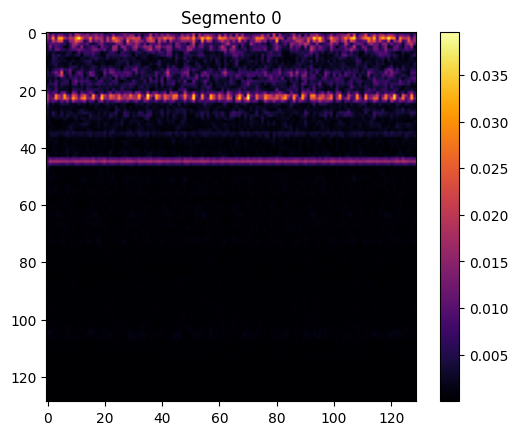

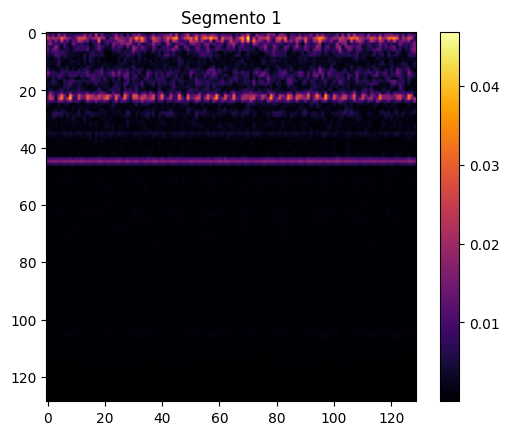

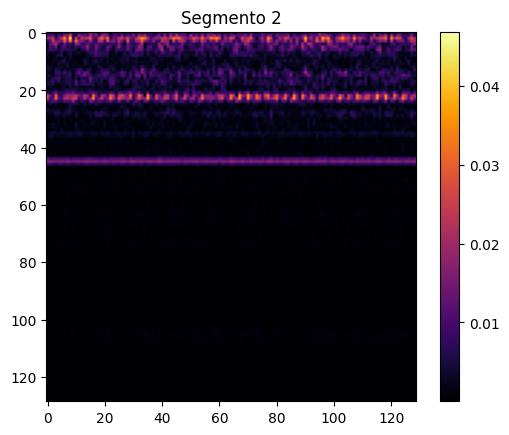

(200448,)


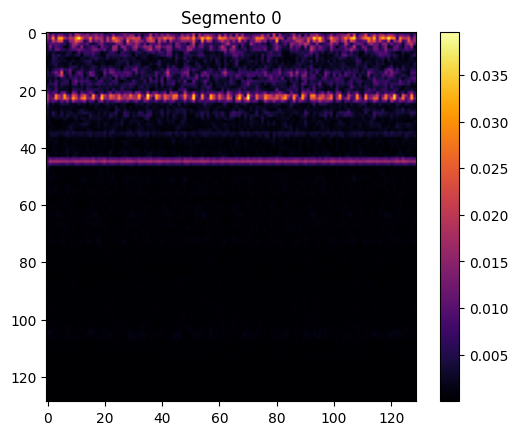

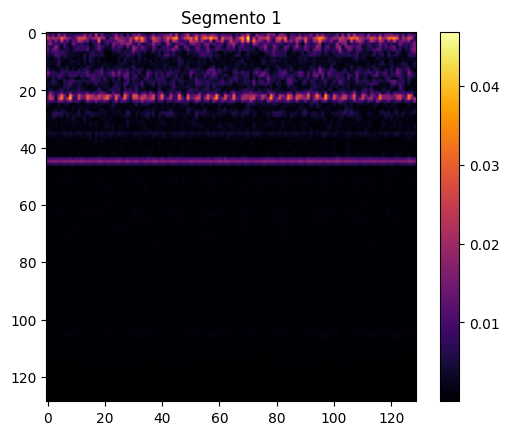

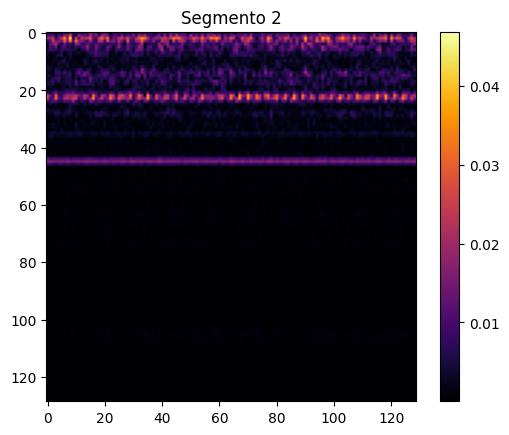

(200448,)


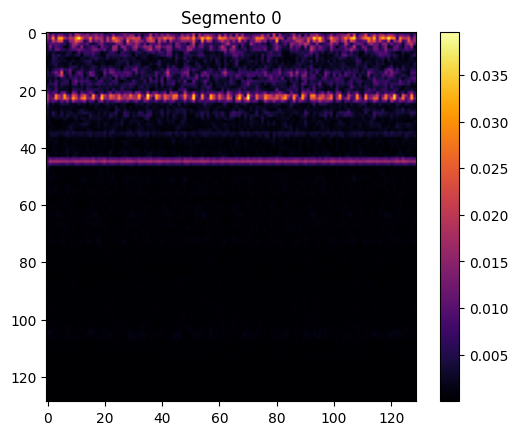

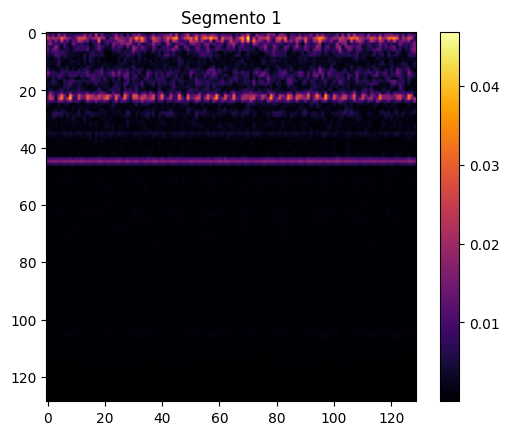

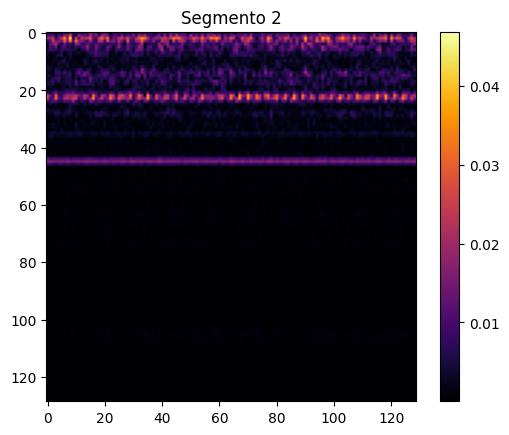

In [ ]:
import numpy as np
import os
from scipy.io import loadmat


# add_gaussian_noise
# local_data_reversing
# local_random_reversing
# global_data_reversing
# local_data_zooming
# global_data_zooming
# local_segment_splicing
# permute_signal

segment_size = 4096
for fold, bearings_files in fold_files.items():
    for key in ['train', 'test', 'val']:
        output_dir = f"data/processed/cwru/{fold}/{key}"
        # output_dir = f"data/spectrograms/cwru_io_1024/{fold}/{key}"
        bearings = bearings_files[key]
        os.makedirs(os.path.join(output_dir), exist_ok=True)
        counter = 0
        for basename, label in bearings:            
            data = loadmat(f"data/raw/cwru/{basename}.mat")
            if basename == 174:
                basename = 173
            if basename in [97, 98, 99]:
                basename = f"0{basename}"
            signal = data[f"X{basename}_DE_time"]
            maxsize_allowed_signal = int(len(signal) // segment_size) * segment_size
            signal = signal[:maxsize_allowed_signal]            
            basename = f"{label}_{basename}"
            for i in range(0, len(signal), segment_size):
                seg = signal[i:i+segment_size][:,0]
                output_path = f"{output_dir}/{basename}_{i//segment_size}"
                np.save(output_path, {"signal": seg, "label": label})
                counter += 1
                
        print(f"Quantidade de segmentos salvos: {counter}")

In [19]:

signal = np.random.randn(200_448)
print(signal)
print(signal.shape)
S = compute_spectrogram(signal)  # Deve funcionar sem erro
print(S.shape)  # Esperado: (129, 1566)


[-0.06305312  0.85182951  0.76526578 ... -0.29393528  0.30812353
 -0.5868947 ]
(200448,)
(129, 1567)


### Gráficos

In [36]:
import re
import matplotlib.pyplot as plt


def plot_vals(log_path):
    # Inicializar listas
    train_losses, val1_losses, val2_losses = [], [], []
    train_accuracies, val1_accuracies, val2_accuracies = [], [], []

    # Padrões regex
    train_val1_pattern = re.compile(
        r"Epoch\s+\[(\d+)/\d+\]\s+-\s+Train Loss:\s+([\d.]+),\s+Train Acc:\s+([\d.]+)\s+-\s+Val1 Loss:\s+([\d.]+),\s+Val1 Acc:\s+([\d.]+)"
    )
    val2_pattern = re.compile(
        r"Epoch\s+\[(\d+)/\d+\]\s+-\s+Val2 Loss:\s+([\d.]+),\s+Val2 Acc:\s+([\d.]+)"
    )

    # Temporária para mapear epoch -> val2
    val2_data = {}

    # Leitura do arquivo
    with open(log_path, 'r') as file:
        for line in file:
            match_train_val1 = train_val1_pattern.search(line)
            match_val2 = val2_pattern.search(line)

            if match_train_val1:
                epoch = int(match_train_val1.group(1))
                train_losses.append(float(match_train_val1.group(2)))
                train_accuracies.append(float(match_train_val1.group(3)))
                val1_losses.append(float(match_train_val1.group(4)))
                val1_accuracies.append(float(match_train_val1.group(5)))

            if match_val2:
                epoch = int(match_val2.group(1))
                val2_data[epoch] = {
                    'loss': float(match_val2.group(2)),
                    'acc': float(match_val2.group(3))
                }

    # Sincronizar val2 com os epochs de train/val1
    for epoch_idx in range(1, len(train_losses) + 1):
        if epoch_idx in val2_data:
            val2_losses.append(val2_data[epoch_idx]['loss'])
            val2_accuracies.append(val2_data[epoch_idx]['acc'])
        else:
            val2_losses.append(None)
            val2_accuracies.append(None)

    # Plotagem dos gráficos
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(14, 6))

    # --- Gráfico de Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val1_losses, label='Val1 Loss')
    plt.plot(epochs, val2_losses, label='Val2 Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs Val1 vs Val2 Loss')
    plt.legend()
    plt.grid(True)

    # --- Gráfico de Acurácia ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val1_accuracies, label='Val1 Accuracy')
    plt.plot(epochs, val2_accuracies, label='Val2 Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Train vs Val1 vs Val2 Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


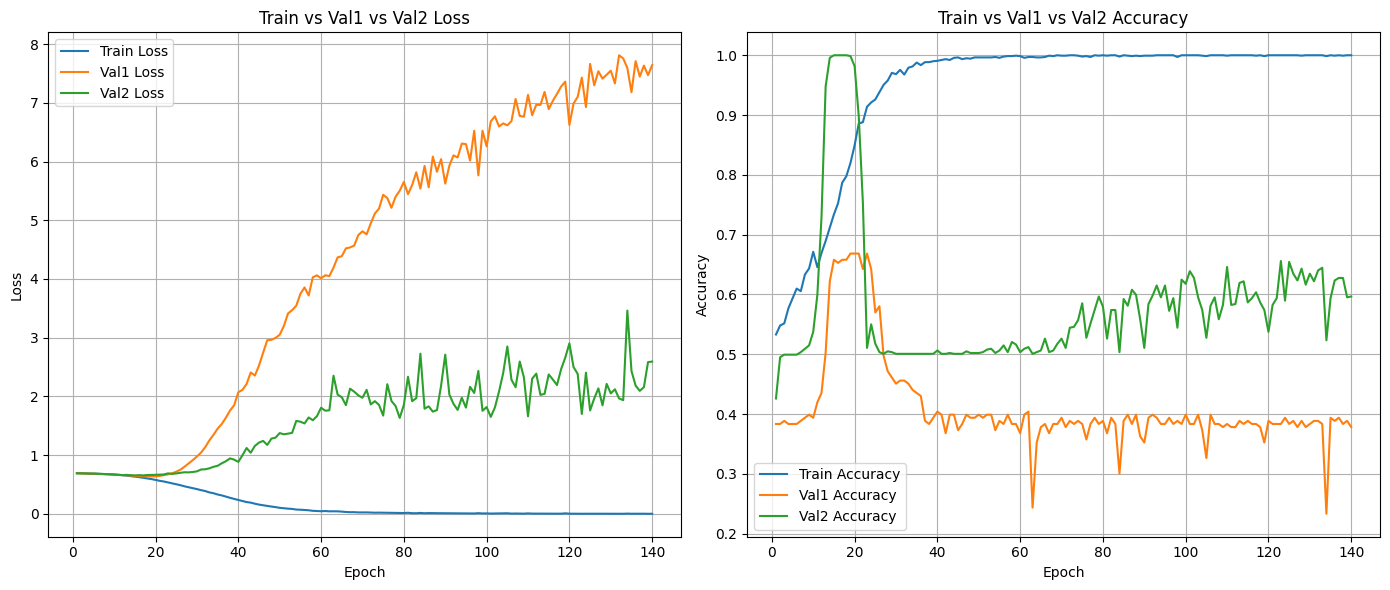

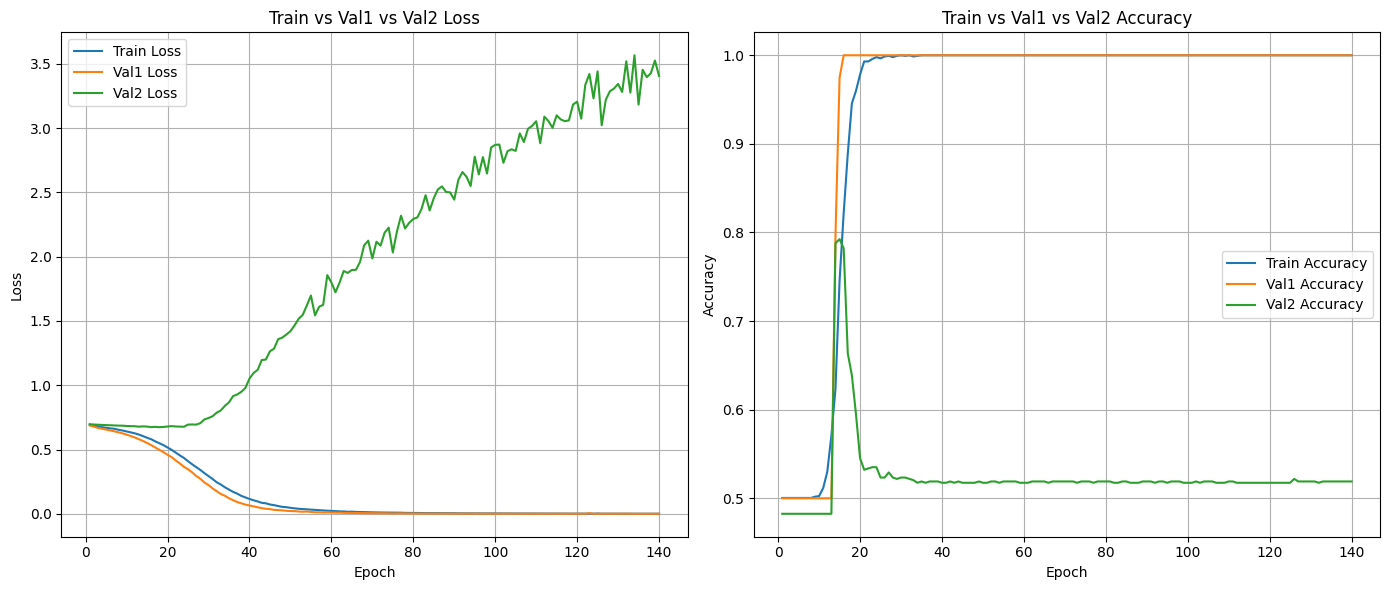

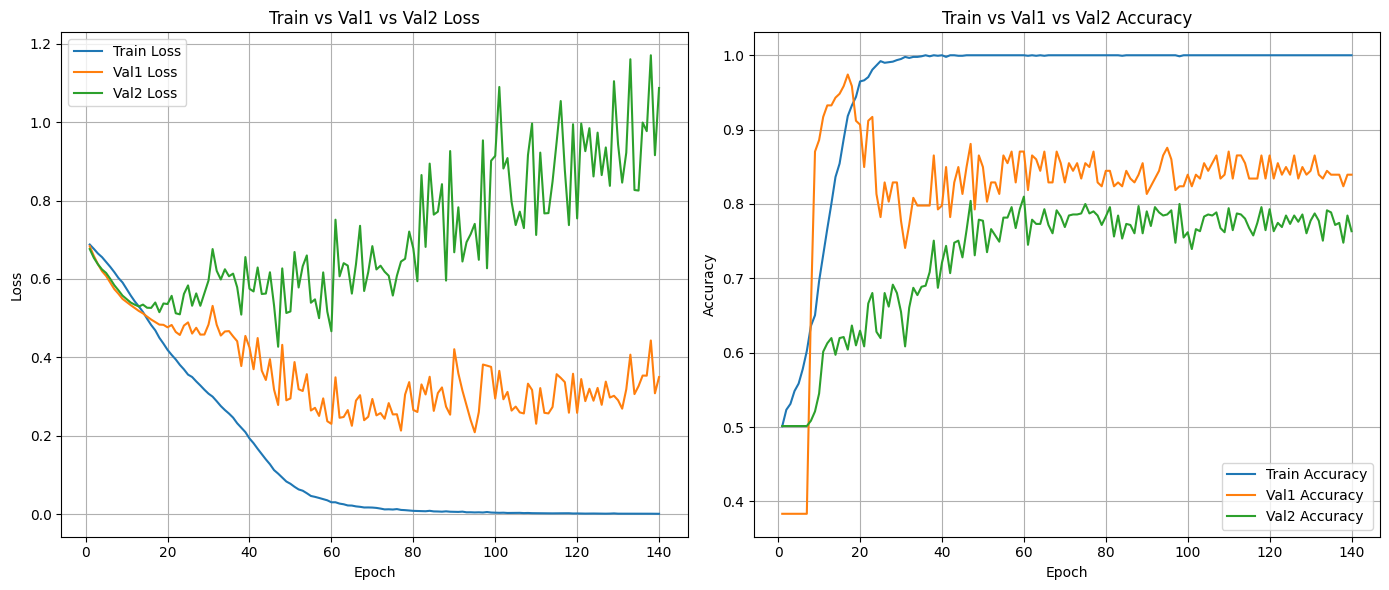

In [39]:
plot_vals("results/experiment1.txt")
plot_vals("results/experiment2.txt")
plot_vals("results/experiment3.txt")

### UORED

In [2]:
import os
import numpy as np
from datasets.uored import UORED

dataset = UORED()

bearings = dataset.load_data({"label": ["N", "B", "I", "O"], "condition_bearing_health": "faulty"})


segment_size = 1024
output_dir = "data/processed/uored"
os.makedirs(os.path.join(output_dir), exist_ok=True)
counter = 0
for data in bearings:
    signal = data[0]
    label = data[1]
    basename = data[3]
    maxsize_allowed_signal = int(len(signal) // segment_size) * segment_size
    # print(f"Max size of signal: {maxsize_allowed_signal}")
    signal = signal[:maxsize_allowed_signal]
    
    for i in range(0, len(signal), segment_size):
        seg = signal[i:i+segment_size] #.astype(np.float32)
        # save_signal_spectrogram(
        #             signal=seg,
        #             save_path=output_dir,
        #             label_name=label,
        #             filename=f"{label}{basename}_{i//segment_size}",
        #             fs=42000,
        #             nperseg=256,
        #             noverlap=128
        #         )
        output_path = f"{output_dir}/{label}{basename}_{i//segment_size}"
        np.save(output_path, {"signal": seg, "label": label})
        counter += 1

print(f"Quantidade de segmentos salvos: {counter}")

Quantidade de segmentos salvos: 6150


#### Quantidade de amostras por dataset

In [23]:
import os

files = []
num_files = len(os.listdir("data/processed/hust_6205_bo"))
print(f"Number of files in Hust dataset: {num_files}")

num_files = len(os.listdir("data/processed/hust_6205_aug_bo"))
print(f"Number of files in Hust dataset with data augmentation: {num_files}")

num_files = len(os.listdir("data/processed/uored_bo"))
print(f"Number of files in UORED dataset: {num_files}")


Number of files in Hust dataset: 702
Number of files in Hust dataset with data augmentation: 234
Number of files in UORED dataset: 1020


### Hust

In [2]:
import os
import numpy as np
from datasets.hust import Hust
from librosa import resample
from src.data_processing.data_augmentation import TransformDataAugmentation

transform = TransformDataAugmentation()

dataset = Hust()

bearings = dataset.load_data({"label": ["I", "O"], "bearing_type": "6205"})


segment_size = 4096
output_dir = "data/processed/hust_6205_io"
os.makedirs(os.path.join(output_dir), exist_ok=True)
counter = 0
for data in bearings:
    signal = data[0]
    label = data[1]
    basename = data[3]
    signal_resampled = resample(signal, orig_sr=51200, target_sr=48000)

    maxsize_allowed_signal = int(len(signal_resampled) // segment_size) * segment_size
    signal_resampled = signal_resampled[:maxsize_allowed_signal]
    
    for i in range(0, len(signal_resampled), segment_size):
        seg = signal_resampled[i:i+segment_size]
        # seg = transform(seg)
        output_path = f"{output_dir}/{basename}_{i//segment_size}"
        np.save(output_path, {"signal": seg, "label": label})
        counter += 1

print(f"Quantidade de segmentos salvos: {counter}")

Quantidade de segmentos salvos: 702


### Paderborn

In [19]:
import os
import numpy as np
from scipy.io import loadmat
from datasets.paderborn import Paderborn
from librosa import resample


dataset = Paderborn()

segment_size = 1024
root_dir = "data/raw/paderborn"
output_dir = "data/spectrograms/paderborn_reduced_io"
os.makedirs(os.path.join(output_dir), exist_ok=True)

selected_dirs = ['KA01', 'KA05', 'KA07', 'KI01', 'KI03', 'KI07']
counter = 0
for dir in selected_dirs:
    files = [f for f in os.listdir(f"{root_dir}/{dir}/{dir}") if f.endswith('.mat')]
    for file in files:
        label = 'O' if dir[1]=='A' else 'I'
        basename = file[:-4]
        if basename[0:3] == 'N09':
            continue
        print(basename, label)
        data = loadmat(f"{root_dir}/{dir}/{dir}/{file}")
        signal = data[basename]['Y'][0][0][0][6][2][0, :]
        signal_resampled = resample(signal, orig_sr=64000, target_sr=48000)
        maxsize_allowed_signal = int(len(signal_resampled) // segment_size) * segment_size
        signal_resampled = signal_resampled[:maxsize_allowed_signal]
        for i in range(0, len(signal_resampled), segment_size):
            seg = signal_resampled[i:i+segment_size]
            output_path = f"{output_dir}/{basename}_{i//segment_size}"
            # np.save(output_path, {"signal": seg, "label": label})
            save_signal_spectrogram(
                    signal=seg,
                    save_path=output_dir,
                    label_name=label,
                    filename=f"{basename}_{i//segment_size}",
                    fs=48000,
                    nperseg=256,
                    noverlap=128
                )
            counter += 1
            if (i//segment_size) == 2:
                break

    print(f"Quantidade de segmentos salvos: {counter}")


N15_M01_F10_KA01_7 O
N15_M07_F10_KA01_16 O
N15_M07_F04_KA01_11 O
N15_M07_F04_KA01_14 O
N15_M07_F04_KA01_19 O
N15_M07_F04_KA01_9 O
N15_M01_F10_KA01_8 O
N15_M07_F04_KA01_17 O
N15_M07_F04_KA01_5 O
N15_M07_F10_KA01_9 O
N15_M01_F10_KA01_13 O
N15_M07_F10_KA01_12 O
N15_M07_F04_KA01_1 O
N15_M07_F10_KA01_15 O
N15_M07_F10_KA01_18 O
N15_M07_F10_KA01_20 O
N15_M01_F10_KA01_4 O
N15_M01_F10_KA01_10 O
N15_M07_F04_KA01_3 O
N15_M07_F10_KA01_7 O
N15_M07_F04_KA01_8 O
N15_M01_F10_KA01_5 O
N15_M01_F10_KA01_16 O
N15_M07_F04_KA01_4 O
N15_M07_F10_KA01_1 O
N15_M01_F10_KA01_11 O
N15_M01_F10_KA01_18 O
N15_M01_F10_KA01_14 O
N15_M07_F04_KA01_20 O
N15_M07_F10_KA01_17 O
N15_M07_F10_KA01_10 O
N15_M07_F10_KA01_3 O
N15_M07_F10_KA01_11 O
N15_M07_F04_KA01_7 O
N15_M07_F04_KA01_18 O
N15_M01_F10_KA01_17 O
N15_M01_F10_KA01_2 O
N15_M01_F10_KA01_1 O
N15_M07_F04_KA01_16 O
N15_M07_F04_KA01_6 O
N15_M07_F10_KA01_6 O
N15_M07_F10_KA01_5 O
N15_M01_F10_KA01_6 O
N15_M07_F04_KA01_15 O
N15_M07_F10_KA01_4 O
N15_M07_F10_KA01_19 O
N15_M01_F1

In [9]:
output_dir = "data/processed/paderborn_reduced_io"

files = [f for f in os.listdir(output_dir) if f.split('_')[3][1]=='I']
len(files)


540

### Classificação Hierárquica

In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from src.models import ModelFactory, CNN1, CNN2, CNN7, CNN8, ADCNN1D, CNN10, HierarchicalClassifier
from src.models.adcnn import ADCNN
from src.data_processing import VibrationDataset, transform_2d

device = 'cuda'

In [3]:
model_factory = ModelFactory(model_class=ADCNN, num_classes=2)
def load_model(path):
    model = model_factory.build().to(device)
    checkpoint = torch.load(path, weights_only=True, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model

In [15]:
root_dir = "data/processed/cwru_1024"
n_fold = 2

classes = sorted(['B', 'I', 'O', 'N'])
labels_map = {label: index for index, label in enumerate(classes)}

test_dataset = VibrationDataset(f"{root_dir}/fold3/test", labels_map=labels_map, transform=transform_2d)
test_loader = DataLoader(test_dataset, batch_size=32)


# Load binary classifiers
clf_nb = load_model(f"checkpoint/adcnn_nb_f{n_fold}.pth")
clf_ni = load_model(f"checkpoint/adcnn_ni_f{n_fold}.pth")
clf_no = load_model(f"checkpoint/adcnn_no_f{n_fold}.pth")
clf_bi = load_model(f"checkpoint/adcnn_bi_f{n_fold}.pth")
clf_bo = load_model(f"checkpoint/adcnn_bi_f{n_fold}.pth")
clf_io = load_model(f"checkpoint/adcnn_bi_f{n_fold}.pth")

total_accuracy = []
for signals, labels in test_loader:
    signals, labels = signals.to(device), labels.to(device)
    result_tensor = torch.zeros((len(labels), 4), device='cuda:0') # [N, B, I, O]
    
    outputs_nb = clf_nb(signals)
    x_nb, predicted_nb = torch.max(outputs_nb, 1)
    outputs_ni = clf_ni(signals)
    x_ni, predicted_ni = torch.max(outputs_ni, 1)
    outputs_no = clf_no(signals)
    x_no, predicted_no = torch.max(outputs_no, 1)
    outputs_bi = clf_bi(signals)
    x_bi, predicted_bi = torch.max(outputs_bi, 1)
    outputs_bo = clf_bo(signals)
    x_bo, predicted_bo = torch.max(outputs_bo, 1)
    outputs_io = clf_io(signals)
    x_io, predicted_io = torch.max(outputs_io, 1)
    # mapa = {0: 'B', 1: 'I', 2: 'I', 3: 'I'}

    for i, label in enumerate(labels.tolist()):

        # x_bi = x_bi / total
        # normal / fault
        total = outputs_nb[:, 0] + outputs_nb[:, 1]
        result_tensor[i, 0] += outputs_nb[i, 0]/total[i] 
        result_tensor[i, 1] += outputs_nb[i, 1]/total[i]

        total = outputs_ni[:, 0] + outputs_ni[:, 1]
        result_tensor[i, 0] += outputs_ni[i, 0]/total[i]
        result_tensor[i, 2] += outputs_ni[i, 1]/total[i]

        total = outputs_no[:, 0] + outputs_no[:, 1]
        result_tensor[i, 0] += outputs_no[i, 0]/total[i]
        result_tensor[i, 3] += outputs_no[i, 1]/total[i]

        print(result_tensor)
        print(labels)
        break

        total = outputs_bi[:, 0] + outputs_bi[:, 1]
        result_tensor[i, 1] += outputs_bi[i, 0]/total[i]
        result_tensor[i, 2] += outputs_bi[i, 1]/total[i]

        result_tensor[i, 1] += outputs_bo[i, 0]/total[i]
        result_tensor[i, 3] += outputs_bo[i, 1]/total[i]

        result_tensor[i, 3] += outputs_io[i, 1]/total[i]
        result_tensor[i, 2] += outputs_io[i, 0]/total[i]
    
        # print(x_bi)
        # print(predicted_bi)
        # print(f"predicted_bi[i] => {predicted_bi[i]}")
        # k = 0 if predicted_bo[i] == torch.tensor(0, device='cuda') else 3
        # total = outputs_bo[:, 0] + outputs_bo[:, 1]
        # x_bo = x_bo / total
        # result_tensor[i, k] += x_bo[i]
        # # print(f"predicted_bo[i] => {predicted_bo[i]}")
        # k = 1 if predicted_io[i] == torch.tensor(0, device='cuda') else 3
        # total = outputs_io[:, 0] + outputs_io[:, 1]
        # x_io = x_io / total
        # result_tensor[i, k] += x_io[i]
        # # print(outputs_io)
        # total = outputs_io[:, 0] + outputs_io[:, 1]
        # print('total ->', total)
        # print(x_io / total)
        # print(predicted_io)
        # print(labels == predicted_io)
        # break
        # print(f"predicted_io[i] => {predicted_io[i]}")

        # print(f"{result_tensor[:i+1, :]}\n-----------------")
    break
    x, predicts = torch.max(result_tensor, 1)
    results = labels == predicts
    # for i in range(32):
    #     print("result_tensor ////// labels")
    #     print(f'{result_tensor[i].tolist()} / {labels[i].tolist()} / {results[i]}')
    x, predicts = torch.max(result_tensor, 1)
    # print("preds ->", predicts)
    # print(labels == predicts)
    total_accuracy.append(sum(labels == predicts)/len(predicts))
    # predicted = [mapa[i] for i in predicted.tolist()]
    # labels = [mapa[i] for i in labels.tolist()]
    # result = [i == j for i, j in zip(labels, predicted)]
    # corrects = [i for i in result if i==True]
    # print(len(corrects))
    # break

    print(f"{sum(total_accuracy)/len(total_accuracy)*100}%")

# # Build hierarchical classifier
# hierarchical_model = HierarchicalClassifier(clf_fn, clf_bi, clf_bo, clf_io).to(device)
# hierarchical_model.eval()

tensor([[7.8408e-05, 9.9993e-01, 9.9999e-01, 1.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.000